### Logistic Regression (Loan Approval Prediction)

**Q1. Data Loading & Understanding**
- a) Load the dataset into Python.
- b) Display the first 5 rows.
- c) Check the shape of the dataset.
- d) Display the data types of each column.

In [11]:
import pandas as pd

# a) Load the dataset into Python
df = pd.read_excel('loan_approval.xlsx')

# b) Display the first 5 rows
df.head()

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25,False


In [12]:
# c) Check the shape of the dataset (Rows, Columns)
print(df.shape)

# d) Display the data types of each column
print(df.dtypes)

(2000, 8)
name              object
city              object
income             int64
credit_score       int64
loan_amount        int64
years_employed     int64
points             int64
loan_approved       bool
dtype: object


**Q2. Data Cleaning**
- a) Check for missing values in the dataset.
- b) Handle missing values appropriately.
- c) Identify categorical columns present in the dataset.

In [13]:
# a) Check for missing values in the dataset
missing_values = df.isnull().sum()
print("Missing values per column:")
missing_values

Missing values per column:


name              0
city              0
income            0
credit_score      0
loan_amount       0
years_employed    0
points            0
loan_approved     0
dtype: int64

In [14]:
# b) Handle missing values appropriately
if missing_values.sum() == 0:
    print("\nNo missing values found. Dataset is already clean.")
else:
    print("\nMissing values detected and handled.")

# c) Identify categorical columns present in the dataset
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("\nCategorical columns identified:")
print(categorical_cols)


No missing values found. Dataset is already clean.

Categorical columns identified:
['name', 'city']


**Q3. Exploratory Data Analysis (EDA)**
- a) Plot the distribution of the target variable.
- b) Analyze the relationship between one numerical feature and the target variable.
- c) Analyze the relationship between Years of Employment and the target variable.

C:\Users\DELL\AppData\Local\Temp\ipykernel_1120\1480443615.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='loan_approved', palette='viridis')


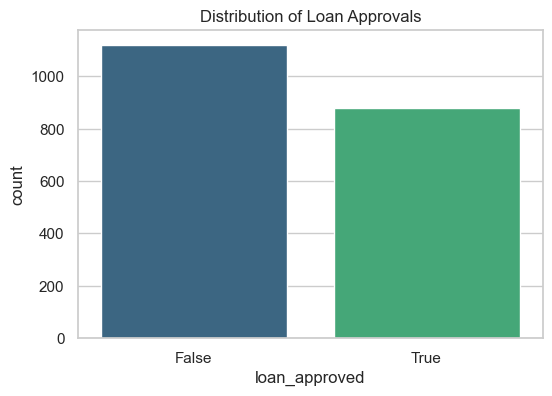

C:\Users\DELL\AppData\Local\Temp\ipykernel_1120\1480443615.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='loan_approved', y='income', palette='magma')


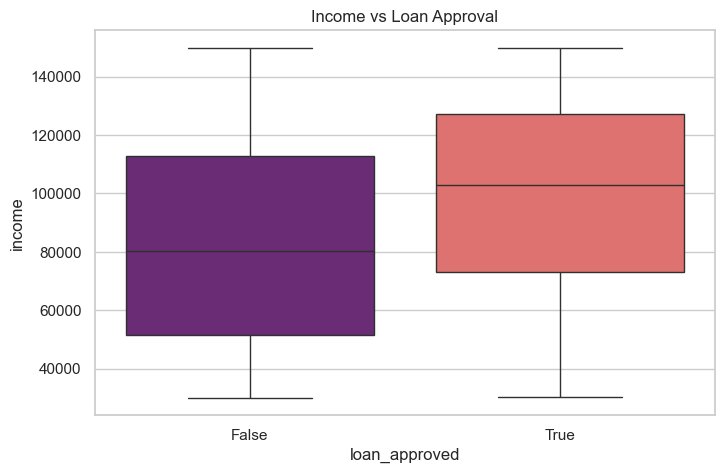

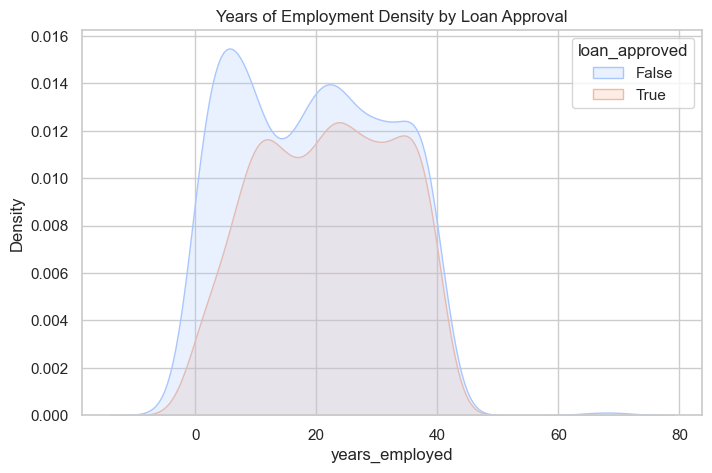

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# a) Plot the distribution of the target variable (loan_approved)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='loan_approved', palette='viridis')
plt.title('Distribution of Loan Approvals')
plt.show()

# b) Relationship between Income (Numerical) and Target
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='loan_approved', y='income', palette='magma')
plt.title('Income vs Loan Approval')
plt.show()

# c) Relationship between Years of Employment and Target
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='years_employed', hue='loan_approved', fill=True, palette='coolwarm')
plt.title('Years of Employment Density by Loan Approval')
plt.show()

**Q4. Outlier Detection and Treatment**
- a) Detect outliers in numerical columns using the IQR method.
- b) Treat outliers using capping techniques

In [16]:
import numpy as np

# Identify numerical columns for analysis
numerical_cols = ['income', 'credit_score', 'loan_amount', 'years_employed', 'points']

# a) Detect outliers using the IQR method
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # b) Treat outliers using capping techniques
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

print("Outlier detection and capping completed for:", numerical_cols)

Outlier detection and capping completed for: ['income', 'credit_score', 'loan_amount', 'years_employed', 'points']


**Q5. Convert target variables into numerical format suitable for model building and drop unnecessary columns.**

In [17]:
# Convert target variable 'loan_approved' from Boolean (True/False) to Integer (1/0)
df['loan_approved'] = df['loan_approved'].astype(int)

df_model = df.drop(columns=['name', 'city'])

print("Remaining columns for model building:")
print(df_model.columns.tolist())

Remaining columns for model building:
['income', 'credit_score', 'loan_amount', 'years_employed', 'points', 'loan_approved']


**Q6. Feature Selection and Data Splitting**
- a) Separate independent variables (X) and dependent variable (y).
- b) Split the dataset into training and testing sets.

In [18]:
from sklearn.model_selection import train_test_split

# a) Separate independent variables (X) and dependent variable (y)
X = df_model.drop(columns=['loan_approved'])
y = df_model['loan_approved']

# b) Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 1600
Testing samples: 400


**Q7. Apply feature scaling to the dataset using StandardScaler.**

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling complete.")

Feature scaling complete.


**Q8. Logistic Regression Model Building**
- a) Train a Logistic Regression model.
- b) Predict the output for test data.

**Q9. Model Evaluation – Confusion Matrix**
- a) Generate the confusion matrix.
- b) Interpret the results.

**Q10. Model Evaluation – ROC Curve & AUC**
- a) Plot the ROC curve.
- b) Calculate the AUC score